<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QG002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

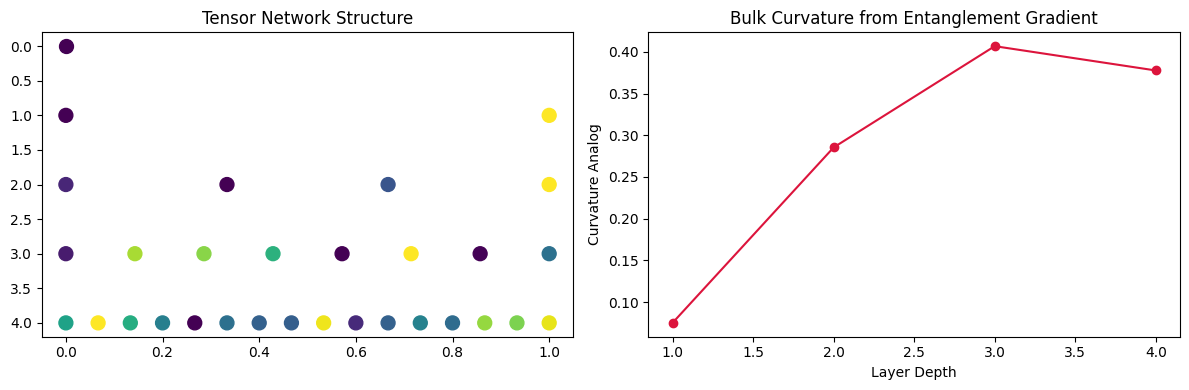

Surface Entanglement Entropy: 7.917


In [1]:
# QG002: Tensor Network → Bulk Curvature
# Author: Chris & Copilot
# Arc IV: Quantum Gravity & Emergent Geometry

import numpy as np
import matplotlib.pyplot as plt

# Parameters
layers = 5  # depth of tensor network
nodes_per_layer = [2**i for i in range(layers)]  # MERA-like expansion
entanglement_surface = []

# Initialize network: each node has entanglement weight
def initialize_network():
    network = []
    for layer in range(layers):
        weights = np.random.rand(nodes_per_layer[layer])
        network.append(weights)
    return network

# Compute surface entanglement (boundary layer)
def compute_surface_entropy(network):
    surface = network[-1]
    return np.sum(surface)

# Estimate bulk curvature from entanglement gradient across layers
def compute_bulk_curvature(network):
    curvature = []
    for i in range(1, layers):
        grad = np.abs(network[i] - np.interp(np.linspace(0, 1, nodes_per_layer[i]),
                                             np.linspace(0, 1, nodes_per_layer[i-1]),
                                             network[i-1]))
        curvature.append(np.mean(grad))
    return curvature

# Visualization
def plot_network(network, curvature):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Tensor network structure
    for i, layer in enumerate(network):
        x = np.linspace(0, 1, len(layer))
        y = np.full_like(x, i)
        axs[0].scatter(x, y, c=layer, cmap='viridis', s=100)
    axs[0].set_title('Tensor Network Structure')
    axs[0].invert_yaxis()

    # Bulk curvature profile
    axs[1].plot(range(1, layers), curvature, marker='o', color='crimson')
    axs[1].set_title('Bulk Curvature from Entanglement Gradient')
    axs[1].set_xlabel('Layer Depth')
    axs[1].set_ylabel('Curvature Analog')

    plt.tight_layout()
    plt.show()

# Run simulation
network = initialize_network()
surface_entropy = compute_surface_entropy(network)
curvature = compute_bulk_curvature(network)
plot_network(network, curvature)

print(f"Surface Entanglement Entropy: {surface_entropy:.3f}")
